In [1]:
import pandas as pd 
import os 
import numpy as np

In [2]:
ds_root_dir = '../data'

In [3]:
prev_app = pd.read_csv(os.path.join(ds_root_dir, "dseb63_previous_application.csv"))


In [4]:
prev_app.head()

,SK_ID_PREV,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,FLAG_LAST_APPL_PER_CONTRACT,...,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL,SK_ID_CURR
0,2030495,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,Y,...,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0,293189
1,1696966,Consumer loans,68258.655,1800000.0,1754721.0,180000.0,1800000.0,SATURDAY,18,Y,...,36.0,low_normal,POS industry with interest,NaN,NaN,NaN,NaN,NaN,NaN,293189
2,2154916,Consumer loans,12417.390,108400.5,119848.5,0.0,108400.5,SUNDAY,14,Y,...,12.0,middle,POS industry with interest,365243.0,-512.0,-182.0,-392.0,-387.0,0.0,293189
3,2802425,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,Y,...,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0,91587
4,1536272,Cash loans,21709.125,450000.0,512370.0,NaN,450000.0,WEDNESDAY,9,Y,...,36.0,low_normal,Cash X-Sell: low,365243.0,-485.0,565.0,-155.0,-147.0,1.0,91587


In [5]:
prev_app

,SK_ID_PREV,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,FLAG_LAST_APPL_PER_CONTRACT,...,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL,SK_ID_CURR
0,2030495,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,Y,...,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0,293189
1,1696966,Consumer loans,68258.655,1800000.0,1754721.0,180000.0,1800000.0,SATURDAY,18,Y,...,36.0,low_normal,POS industry with interest,NaN,NaN,NaN,NaN,NaN,NaN,293189
2,2154916,Consumer loans,12417.390,108400.5,119848.5,0.0,108400.5,SUNDAY,14,Y,...,12.0,middle,POS industry with interest,365243.0,-512.0,-182.0,-392.0,-387.0,0.0,293189
3,2802425,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,Y,...,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0,91587
4,1536272,Cash loans,21709.125,450000.0,512370.0,NaN,450000.0,WEDNESDAY,9,Y,...,36.0,low_normal,Cash X-Sell: low,365243.0,-485.0,565.0,-155.0,-147.0,1.0,91587
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1413696,1261221,Consumer loans,6030.675,133866.0,133866.0,0.0,133866.0,SATURDAY,15,Y,...,24.0,low_action,POS household without interest,365243.0,-801.0,-111.0,-531.0,-518.0,0.0,302680
1413697,1563733,Consumer loans,13726.080,137250.0,123525.0,13725.0,137250.0,SATURDAY,14,Y,...,10.0,low_normal,POS household with interest,365243.0,-464.0,-194.0,-194.0,-186.0,0.0,192560
1413698,2319569,Consumer loans,4716.495,46800.0,46800.0,0.0,46800.0,FRIDAY,9,Y,...,12.0,middle,POS industry with interest,365243.0,-119.0,211.0,365243.0,365243.0,0.0,91682
1413699,2829648,Consumer loans,10301.940,101745.0,112491.0,0.0,101745.0,FRIDAY,12,Y,...,12.0,low_action,POS household without interest,365243.0,-529.0,-199.0,-199.0,-194.0,0.0,126653


In [6]:
prev_app['DATE_DIFF'] = prev_app['DAYS_TERMINATION'] - prev_app['DAYS_LAST_DUE']


In [7]:
good_replace = ['Gardening', 'Animals', 'Insurance', 'Medicine', 'Fitness', 'Direct Sales', 'Additional Service', 'Education', 'Weapon', ]

In [8]:
prev_app['NAME_GOODS_CATEGORY'] = prev_app['NAME_GOODS_CATEGORY'].replace(good_replace, 'Other')

In [9]:
prev_app['NAME_CASH_LOAN_PURPOSE'].value_counts()

NAME_CASH_LOAN_PURPOSE
XAP                                 786937
XNA                                 567351
Repairs                              20117
Other                                13432
Urgent needs                          7236
Buying a used car                     2469
Building a house or an annex          2344
Everyday expenses                     2052
Medicine                              1871
Payments on other loans               1573
Education                             1334
Journey                               1042
Purchase of electronic equipment       934
Buying a new car                       886
Wedding / gift / holiday               801
Buying a home                          701
Car repairs                            691
Furniture                              660
Buying a holiday home / land           463
Business development                   359
Gasification / water supply            251
Buying a garage                        116
Hobby                          

In [10]:
prev_app['NAME_CASH_LOAN_PURPOSE'].replace({'Wedding / gift / holiday':'Journey', 'Hobby': 'Everyday expenses'}, inplace=True)

/tmp/ipykernel_2216856/2784239544.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  prev_app['NAME_CASH_LOAN_PURPOSE'].replace({'Wedding / gift / holiday':'Journey', 'Hobby': 'Everyday expenses'}, inplace=True)


In [11]:
loan_purpose = ['Refusal to name the goal', 'Money for a third person', 'Buying a garage', 'Buying a garage', 'Gasification / water supply', 'Business development', 'Buying a holiday home / land', 'Furniture', 'Car repairs', 'Buying a home',  'Purchase of electronic equipment', 'Journey', 'Education', 'Payments on other loans', 'Medicine', 'Building a house or an annex']
prev_app['NAME_CASH_LOAN_PURPOSE'] = prev_app['NAME_CASH_LOAN_PURPOSE'].replace(loan_purpose, 'Other')
prev_app['NAME_CASH_LOAN_PURPOSE'] = prev_app['NAME_CASH_LOAN_PURPOSE'].replace(['Buying a new car', 'Buying a used car'], 'Buying a car')

In [12]:
prev_app['NAME_GOODS_CATEGORY'].value_counts()

NAME_GOODS_CATEGORY
XNA                         797209
Mobile                      193743
Consumer Electronics        104785
Computers                    89923
Audio/Video                  85502
Furniture                    45439
Photo / Cinema Equipment     21707
Construction Materials       21356
Clothing and Accessories     19590
Other                         6779
Auto Accessories              6228
Jewelry                       5188
Homewares                     4309
Medical Supplies              3240
Vehicles                      2854
Sport and Leisure             2540
Office Appliances             1985
Tourism                       1324
Name: count, dtype: int64

In [13]:
prev_app.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1413701 entries, 0 to 1413700
Data columns (total 38 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1413701 non-null  int64  
 1   NAME_CONTRACT_TYPE           1413701 non-null  object 
 2   AMT_ANNUITY                  1106483 non-null  float64
 3   AMT_APPLICATION              1413701 non-null  float64
 4   AMT_CREDIT                   1413700 non-null  float64
 5   AMT_DOWN_PAYMENT             664161 non-null   float64
 6   AMT_GOODS_PRICE              1094176 non-null  float64
 7   WEEKDAY_APPR_PROCESS_START   1413701 non-null  object 
 8   HOUR_APPR_PROCESS_START      1413701 non-null  int64  
 9   FLAG_LAST_APPL_PER_CONTRACT  1413701 non-null  object 
 10  NFLAG_LAST_APPL_IN_DAY       1413701 non-null  int64  
 11  RATE_DOWN_PAYMENT            664161 non-null   float64
 12  RATE_INTEREST_PRIMARY        4791 non-null

In [14]:
prev_app['FLAG_LAST_APPL_PER_CONTRACT'] = prev_app['FLAG_LAST_APPL_PER_CONTRACT'].map({'Y': 1, 'N': 0}).astype(int)


In [15]:
prev_app['NAME_TYPE_SUITE'].replace('Children', 'Family', inplace=True)
prev_app['NAME_TYPE_SUITE'].replace('Other_A', 'Other', inplace=True)
prev_app['NAME_TYPE_SUITE'].replace('Other_B', 'Other', inplace=True)
prev_app['NAME_TYPE_SUITE'].replace('Group of people', 'Other', inplace=True)
prev_app['NAME_TYPE_SUITE'].replace('Spouse, partner', 'Family', inplace=True)
prev_app['NAME_TYPE_SUITE'].replace('Unaccompanied', 'Single', inplace=True)

/tmp/ipykernel_2216856/2338902145.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  prev_app['NAME_TYPE_SUITE'].replace('Children', 'Family', inplace=True)
/tmp/ipykernel_2216856/2338902145.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].metho

In [16]:
def display_missing_data_info(dataframe, ascending=False):
    missing_values_count = dataframe.isnull().sum()
    missing_values_percentage = (dataframe.isnull().mean() * 100)
    missing_data = pd.DataFrame({
        'Missing Values': missing_values_count,
        'Percentage (%)': missing_values_percentage
    })
    
    missing_data = missing_data[missing_data['Missing Values'] > 0]
    
    sorted_missing_data = missing_data.sort_values(by='Missing Values', ascending=ascending)

    #print(sorted_missing_data)
    return sorted_missing_data

In [17]:
display_missing_data_info(prev_app)

,Missing Values,Percentage (%)
RATE_INTEREST_PRIMARY,1408910,99.661102
RATE_INTEREST_PRIVILEGED,1408910,99.661102
AMT_DOWN_PAYMENT,749540,53.019698
RATE_DOWN_PAYMENT,749540,53.019698
NAME_TYPE_SUITE,694672,49.138538
DATE_DIFF,561106,39.690571
DAYS_LAST_DUE,561106,39.690571
NFLAG_INSURED_ON_APPROVAL,561106,39.690571
DAYS_TERMINATION,561106,39.690571
DAYS_FIRST_DRAWING,561106,39.690571


In [18]:
prev_app.shape

(1413701, 38)

In [19]:
# prev_app['RATE_INTEREST_PRIMARY'].fillna(0, inplace=True)
# prev_app['RATE_INTEREST_PRIVILEGED'].fillna(0, inplace=True)
# prev_app['AMT_DOWN_PAYMENT'].fillna(0, inplace=True)
# prev_app['RATE_DOWN_PAYMENT'].fillna(0, inplace=True)

In [20]:
prev_app.replace({'NAME_YIELD_GROUP': {'XNA': 0, 'low_action': 1, 'low_normal': 1, 'middle': 3, 'high': 4}}, inplace=True)
prev_app['NAME_YIELD_GROUP'].fillna(0, inplace=True)

/tmp/ipykernel_2216856/1332785848.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  prev_app.replace({'NAME_YIELD_GROUP': {'XNA': 0, 'low_action': 1, 'low_normal': 1, 'middle': 3, 'high': 4}}, inplace=True)
/tmp/ipykernel_2216856/1332785848.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  prev_

In [21]:
prev_app.columns

Index(['SK_ID_PREV', 'NAME_CONTRACT_TYPE', 'AMT_ANNUITY', 'AMT_APPLICATION',
       'AMT_CREDIT', 'AMT_DOWN_PAYMENT', 'AMT_GOODS_PRICE',
       'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START',
       'FLAG_LAST_APPL_PER_CONTRACT', 'NFLAG_LAST_APPL_IN_DAY',
       'RATE_DOWN_PAYMENT', 'RATE_INTEREST_PRIMARY',
       'RATE_INTEREST_PRIVILEGED', 'NAME_CASH_LOAN_PURPOSE',
       'NAME_CONTRACT_STATUS', 'DAYS_DECISION', 'NAME_PAYMENT_TYPE',
       'CODE_REJECT_REASON', 'NAME_TYPE_SUITE', 'NAME_CLIENT_TYPE',
       'NAME_GOODS_CATEGORY', 'NAME_PORTFOLIO', 'NAME_PRODUCT_TYPE',
       'CHANNEL_TYPE', 'SELLERPLACE_AREA', 'NAME_SELLER_INDUSTRY',
       'CNT_PAYMENT', 'NAME_YIELD_GROUP', 'PRODUCT_COMBINATION',
       'DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE', 'DAYS_LAST_DUE_1ST_VERSION',
       'DAYS_LAST_DUE', 'DAYS_TERMINATION', 'NFLAG_INSURED_ON_APPROVAL',
       'SK_ID_CURR', 'DATE_DIFF'],
      dtype='object')

In [22]:
print(prev_app['SK_ID_CURR'].nunique())
print(prev_app['SK_ID_PREV'].nunique())

291057
1413701


There are repetitions in IDs in prev applications -> need to agg; prev id is unique

In [23]:
nan_as_category = False
num_rows = None 

In [24]:
def OHE(df, nan_as_category = True):
    original_cols = list(df.columns)
    categorical_columns = [col for col in df.columns if df[col].dtype == 'object']
    for col in categorical_columns:
        df[col].fillna('XNA', inplace=True)

    df = pd.get_dummies(df, columns= categorical_columns,
                        dummy_na= nan_as_category)
    new_columns = [c for c in df.columns if c not in original_cols]
    return df, new_columns

In [25]:
## Hung feat
prev_app['ACTIVE'] = prev_app['DAYS_LAST_DUE'] > 0
prev_app['ACTUAL_DURATION'] = prev_app['DAYS_LAST_DUE'] - prev_app['DAYS_FIRST_DUE']
prev_app['DURATION'] = prev_app['DAYS_TERMINATION'] - prev_app['DAYS_FIRST_DUE']
prev_app['LIFETIME_LOAN'] = prev_app['DAYS_TERMINATION'] > 16000

prev_app['FINISH_RATE'] = (prev_app['ACTUAL_DURATION'] / prev_app['DURATION']) * (1 - prev_app['ACTIVE']) * (1 - prev_app['LIFETIME_LOAN'])

<Axes: >

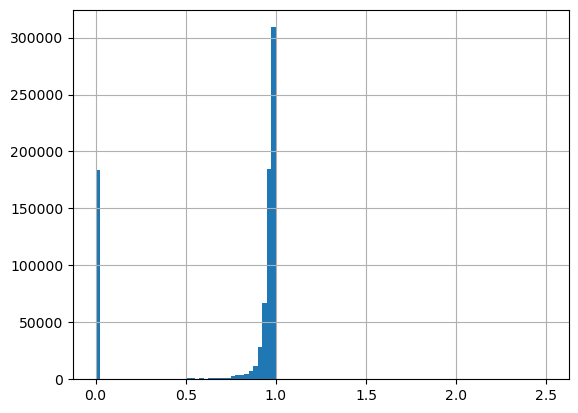

In [26]:
prev_app['FINISH_RATE'].hist(bins=100)

In [27]:
prev_app

,SK_ID_PREV,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,FLAG_LAST_APPL_PER_CONTRACT,...,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL,SK_ID_CURR,DATE_DIFF,ACTIVE,ACTUAL_DURATION,DURATION,LIFETIME_LOAN,FINISH_RATE
0,2030495,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,1,...,-42.0,-37.0,0.0,293189,5.0,False,0.0,5.0,False,0.000000
1,1696966,Consumer loans,68258.655,1800000.0,1754721.0,180000.0,1800000.0,SATURDAY,18,1,...,NaN,NaN,NaN,293189,NaN,False,NaN,NaN,False,NaN
2,2154916,Consumer loans,12417.390,108400.5,119848.5,0.0,108400.5,SUNDAY,14,1,...,-392.0,-387.0,0.0,293189,5.0,False,120.0,125.0,False,0.960000
3,2802425,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,1,...,365243.0,365243.0,1.0,91587,0.0,True,365377.0,365377.0,True,0.000000
4,1536272,Cash loans,21709.125,450000.0,512370.0,NaN,450000.0,WEDNESDAY,9,1,...,-155.0,-147.0,1.0,91587,8.0,False,330.0,338.0,False,0.976331
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1413696,1261221,Consumer loans,6030.675,133866.0,133866.0,0.0,133866.0,SATURDAY,15,1,...,-531.0,-518.0,0.0,302680,13.0,False,270.0,283.0,False,0.954064
1413697,1563733,Consumer loans,13726.080,137250.0,123525.0,13725.0,137250.0,SATURDAY,14,1,...,-194.0,-186.0,0.0,192560,8.0,False,270.0,278.0,False,0.971223
1413698,2319569,Consumer loans,4716.495,46800.0,46800.0,0.0,46800.0,FRIDAY,9,1,...,365243.0,365243.0,0.0,91682,0.0,True,365362.0,365362.0,True,0.000000
1413699,2829648,Consumer loans,10301.940,101745.0,112491.0,0.0,101745.0,FRIDAY,12,1,...,-199.0,-194.0,0.0,126653,5.0,False,330.0,335.0,False,0.985075


In [28]:
#New features from old features

#Ratio: value ask / value received percentage 
prev_app = prev_app.drop(prev_app[prev_app['AMT_CREDIT'].isnull() == True].index) 
prev_app['APP_CREDIT_PERC'] = prev_app['AMT_APPLICATION'] / prev_app['AMT_CREDIT']
prev_app['ANNUITY_PAYMENT_PRODUCT'] = prev_app['AMT_ANNUITY'] * prev_app['CNT_PAYMENT']
prev_app['HIGH_DOWN_PAYMENT'] = (prev_app['AMT_DOWN_PAYMENT'] > 10000)

prev_app['CREDIT_ANNUITY_RATIO'] = prev_app['AMT_CREDIT'] / prev_app['AMT_ANNUITY'] * (prev_app['AMT_ANNUITY'] != 0)
prev_app['CREDIT_DOWNPAYMENT'] = prev_app['AMT_GOODS_PRICE'] - prev_app['AMT_DOWN_PAYMENT']
prev_app['RATIO_APPLICATION_TO_ANNUITY'] =  prev_app['AMT_APPLICATION'] / prev_app['AMT_ANNUITY']
prev_app['RATIO_GOODS_TO_ANNUITY'] =  prev_app['AMT_GOODS_PRICE'] / prev_app['AMT_ANNUITY']

#Churn_prev: Whether the payment date is late 
# 1= delayed, 0 = not delayed, NaN = null
k = prev_app.DAYS_LAST_DUE_1ST_VERSION - prev_app.DAYS_LAST_DUE
prev_app["CHURN_PREV"] = [1 if i >= 0 else (0 if i < 0  else "NaN") for i in k]

prev_app['AMT_DIFF_PERCENT'] = ((prev_app['AMT_CREDIT'] - prev_app['AMT_APPLICATION']) / prev_app['AMT_APPLICATION']) * 100
prev_app['ADJUSTMENT_DIRECTION'] = (prev_app['AMT_CREDIT'] - prev_app['AMT_APPLICATION']) >= 0
prev_app['ADJUSTMENT_DIRECTION'] = prev_app['ADJUSTMENT_DIRECTION'].map({'True': 1, 'False': 0}) #whether final credit amount is equal clients' application 

#Interest rate
prev_app['INTEREST'] = prev_app['CNT_PAYMENT']*prev_app['AMT_ANNUITY'] - prev_app['AMT_CREDIT']
prev_app['INTEREST_RATE'] = 2*12*prev_app['INTEREST']/(prev_app['AMT_CREDIT']*(prev_app['CNT_PAYMENT']+1))
prev_app['INTEREST_SHARE'] = prev_app['INTEREST']/prev_app['AMT_CREDIT']


prev_app["DAYS_DECISION"] = [1 if abs(i/(12*30)) <=1 else 0 for i in prev_app.DAYS_DECISION]

#Separate weekend from weekdays
prev_app["WEEKDAY_APPR_PROCESS_START"] = prev_app["WEEKDAY_APPR_PROCESS_START"].replace(['MONDAY','TUESDAY', 'WEDNESDAY','THURSDAY','FRIDAY'], 'WEEK_DAY')
prev_app["WEEKDAY_APPR_PROCESS_START"] = prev_app["WEEKDAY_APPR_PROCESS_START"].replace(['SATURDAY', 'SUNDAY'], 'WEEKEND')
prev_app["WEEKDAY_APPR_PROCESS_START"].fillna('WEEK_DAY', inplace=True)

#Separate working hours from off_hours
prev_app["HOUR_APPR_PROCESS_START"] = prev_app["HOUR_APPR_PROCESS_START"].replace([8,9,10,11,12,13,14,15,16,17], 'working_hours')
prev_app["HOUR_APPR_PROCESS_START"] = prev_app["HOUR_APPR_PROCESS_START"].replace([18,19,20,21,22,23,0,1,2,3,4,5,6,7], 'off_hours')

/tmp/ipykernel_2216856/3704017348.py:34: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  prev_app["WEEKDAY_APPR_PROCESS_START"].fillna('WEEK_DAY', inplace=True)


In [29]:
prev_app["HOUR_APPR_PROCESS_START"].value_counts()

HOUR_APPR_PROCESS_START
working_hours    1227751
off_hours         185949
Name: count, dtype: int64

In [30]:
 # NEW_INSURANCE variable has been defined to be used instead of NFLAG_INSURED_ON_APPROVAL variable.
#    df_prev[(df_prev['AMT_CREDIT'] == 0) | (df_prev['AMT_GOODS_PRICE'] == 0)]['NEW_INSURANCE'] = np.nan
 #   df_prev['sigorta_miktari'] = df_prev['AMT_CREDIT'] - df_prev['AMT_GOODS_PRICE']
 #   df_prev["NEW_INSURANCE"] = df_prev['sigorta_miktari'].apply(lambda x: 1 if x > 0 else (0 if x <= 0 else np.nan))
 #   df_prev.drop('sigorta_miktari', axis=1, inplace=True)

In [31]:
prev_app, cat_cols = OHE(prev_app, nan_as_category=False)

/tmp/ipykernel_2216856/3163332172.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna('XNA', inplace=True)


In [32]:
np.nan <0

False

In [33]:
print(len(cat_cols))
print(cat_cols)

106
['NAME_CONTRACT_TYPE_Cash loans', 'NAME_CONTRACT_TYPE_Consumer loans', 'NAME_CONTRACT_TYPE_Revolving loans', 'NAME_CONTRACT_TYPE_XNA', 'WEEKDAY_APPR_PROCESS_START_WEEKEND', 'WEEKDAY_APPR_PROCESS_START_WEEK_DAY', 'HOUR_APPR_PROCESS_START_off_hours', 'HOUR_APPR_PROCESS_START_working_hours', 'NAME_CASH_LOAN_PURPOSE_Buying a car', 'NAME_CASH_LOAN_PURPOSE_Everyday expenses', 'NAME_CASH_LOAN_PURPOSE_Other', 'NAME_CASH_LOAN_PURPOSE_Repairs', 'NAME_CASH_LOAN_PURPOSE_Urgent needs', 'NAME_CASH_LOAN_PURPOSE_XAP', 'NAME_CASH_LOAN_PURPOSE_XNA', 'NAME_CONTRACT_STATUS_Approved', 'NAME_CONTRACT_STATUS_Canceled', 'NAME_CONTRACT_STATUS_Refused', 'NAME_CONTRACT_STATUS_Unused offer', 'NAME_PAYMENT_TYPE_Cash through the bank', 'NAME_PAYMENT_TYPE_Cashless from the account of the employer', 'NAME_PAYMENT_TYPE_Non-cash from your account', 'NAME_PAYMENT_TYPE_XNA', 'CODE_REJECT_REASON_CLIENT', 'CODE_REJECT_REASON_HC', 'CODE_REJECT_REASON_LIMIT', 'CODE_REJECT_REASON_SCO', 'CODE_REJECT_REASON_SCOFR', 'CODE_RE

In [34]:
prev_app.dtypes.value_counts()

bool       109
float64     30
int64        7
Name: count, dtype: int64

Aggregations

In [35]:
num_aggregations = {
                     'AMT_ANNUITY':             ['sum','min', 'max', 'mean', 'std', 'skew'],
                     'AMT_APPLICATION':         ['sum','min', 'max', 'mean', 'std', 'skew'],
                     'AMT_CREDIT':              ['sum','min', 'max', 'mean', 'std', 'skew'],
                     'APP_CREDIT_PERC':         ['sum','min', 'max', 'mean', 'var'],
                     'AMT_DOWN_PAYMENT':        [ 'sum','min', 'max', 'mean', 'std', 'skew'],
                     'AMT_GOODS_PRICE':         ['sum','min', 'max', 'mean', 'std', 'skew'],
                     'CREDIT_ANNUITY_RATIO':    ['mean', 'std' ],
                     
                     # 'HOUR_APPR_PROCESS_START': ['min', 'max', 'mean'],
                     'RATE_DOWN_PAYMENT':       ['min', 'max', 'mean', 'var'],
                     'DAYS_DECISION':           ['min', 'max', 'mean'],
                     'CNT_PAYMENT':             ['mean', 'sum'],

                     'HIGH_DOWN_PAYMENT':      ['sum'],
                     'ANNUITY_PAYMENT_PRODUCT': ['sum', 'mean', 'std', ],
                     'RATIO_APPLICATION_TO_ANNUITY': ['mean', 'std'],
                        'RATIO_GOODS_TO_ANNUITY': ['mean', 'std'],
                    }

num_refuse_aggregations = {
                     'AMT_ANNUITY':             ['sum','min', 'max', 'mean', 'std', 'skew'],
                     'AMT_APPLICATION':         ['sum','min', 'max', 'mean', 'std', 'skew'],
                     'AMT_CREDIT':              ['sum','min', 'max', 'mean', 'std', 'skew'],
                     'APP_CREDIT_PERC':         ['sum','min', 'max', 'mean', 'var'],
                     'AMT_DOWN_PAYMENT':        [ 'sum','min', 'max', 'mean', 'std'],
                     'AMT_GOODS_PRICE':         ['sum','min', 'max', 'mean', 'std', 'skew'],
                     'CREDIT_ANNUITY_RATIO':    ['mean', 'std' ],
                     
                     # 'HOUR_APPR_PROCESS_START': ['min', 'max', 'mean'],
                     'RATE_DOWN_PAYMENT':       ['min', 'max', 'mean'],
                     'DAYS_DECISION':           ['min', 'max', 'mean'],
                     'CNT_PAYMENT':             ['mean', 'sum'],

                     'ANNUITY_PAYMENT_PRODUCT': ['sum', 'mean', 'std', ],
                     'RATIO_APPLICATION_TO_ANNUITY': ['mean', 'std'],
                        'RATIO_GOODS_TO_ANNUITY': ['mean', 'std'],
                    }

In [36]:
cat_aggregations = {}
cat_approve_aggegations = {}
for cat in cat_cols:
    if 'NAME_CONTRACT' in cat:
        cat_aggregations[cat] = ['mean', 'sum']
        cat_approve_aggegations[cat] = ['sum']

    if 'WEEKDAY' in cat or 'HOUR' in cat:
        cat_aggregations[cat] = ['mean', 'sum']
        cat_approve_aggegations[cat] = ['sum']

    if 'CHUN_PREV' in cat:
        cat_aggregations[cat] = ['sum', 'mean']
        cat_approve_aggegations[cat] = ['sum']
      
    if 'PURPOSE' in cat:
        cat_aggregations[cat] = ['sum']
        cat_approve_aggegations[cat] = ['sum']

    if 'CODE_REJECT_REASON' in cat:
        cat_aggregations[cat] = ['sum']
        
    if cat not in cat_aggregations:
        cat_aggregations[cat] = ['mean']
cat_aggregations  

{'NAME_CONTRACT_TYPE_Cash loans': ['mean', 'sum'],
 'NAME_CONTRACT_TYPE_Consumer loans': ['mean', 'sum'],
 'NAME_CONTRACT_TYPE_Revolving loans': ['mean', 'sum'],
 'NAME_CONTRACT_TYPE_XNA': ['mean', 'sum'],
 'WEEKDAY_APPR_PROCESS_START_WEEKEND': ['mean', 'sum'],
 'WEEKDAY_APPR_PROCESS_START_WEEK_DAY': ['mean', 'sum'],
 'HOUR_APPR_PROCESS_START_off_hours': ['mean', 'sum'],
 'HOUR_APPR_PROCESS_START_working_hours': ['mean', 'sum'],
 'NAME_CASH_LOAN_PURPOSE_Buying a car': ['sum'],
 'NAME_CASH_LOAN_PURPOSE_Everyday expenses': ['sum'],
 'NAME_CASH_LOAN_PURPOSE_Other': ['sum'],
 'NAME_CASH_LOAN_PURPOSE_Repairs': ['sum'],
 'NAME_CASH_LOAN_PURPOSE_Urgent needs': ['sum'],
 'NAME_CASH_LOAN_PURPOSE_XAP': ['sum'],
 'NAME_CASH_LOAN_PURPOSE_XNA': ['sum'],
 'NAME_CONTRACT_STATUS_Approved': ['mean', 'sum'],
 'NAME_CONTRACT_STATUS_Canceled': ['mean', 'sum'],
 'NAME_CONTRACT_STATUS_Refused': ['mean', 'sum'],
 'NAME_CONTRACT_STATUS_Unused offer': ['mean', 'sum'],
 'NAME_PAYMENT_TYPE_Cash through the bank'

In [37]:
grouped = prev_app.groupby('SK_ID_CURR')
prev_agg=grouped.agg({**num_aggregations, **cat_aggregations})

In [38]:
prev_agg.shape   
prev_agg.columns
prev_agg.head()

AMT_ANNUITY                                                  \
                   sum       min        max         mean           std   
SK_ID_CURR                                                               
0            39954.825  2250.000  11180.385   6659.13750   3756.296439   
1            38727.315  2250.000  25996.365  12909.10500  12057.960657   
2            38822.580  2457.675  24577.425   9705.64500  10316.370832   
3            19535.355  3404.520   6750.000   4883.83875   1693.406723   
4             8957.430  8957.430   8957.430   8957.43000           NaN   

                     AMT_APPLICATION                                   ...  \
                skew             sum      min       max          mean  ...   
SK_ID_CURR                                                             ...   
0           0.419875      470394.000  25200.0  120658.5  78399.000000  ...   
1           0.869434      478125.000      0.0  337500.0  68303.571429  ...   
2           1.584021      340920.495  16420.5  225000.0  85230.123750  ...   
3           0.218194      248895.000      0.0  135000.0  41482.500000  ...   
4                NaN       47250.000  47250.0   47250.0  47250.000000  ...   

           PRODUCT_COMBINATION_POS industry with interest  \
                                                     mean   
SK_ID_CURR                                                  
0                                                0.166667   
1                                                0.000000   
2                                                0.250000   
3                                                0.000000   
4                                                0.000000   

           PRODUCT_COMBINATION_POS industry without interest  \
                                                        mean   
SK_ID_CURR                                                     
0                                                       0.00   
1                                                       0.00   
2                                                       0.25   
3                                                       0.00   
4                                                       0.00   

           PRODUCT_COMBINATION_POS mobile with interest  \
                                                   mean   
SK_ID_CURR                                                
0                                                  0.00   
1                                                  0.00   
2                                                  0.25   
3                                                  0.00   
4                                                  0.00   

           PRODUCT_COMBINATION_POS mobile without interest  \
                                                      mean   
SK_ID_CURR                                                   
0                                                      0.0   
1                                                      0.0   
2                                                      0.0   
3                                                      0.0   
4                                                      0.0   

           PRODUCT_COMBINATION_POS other with interest  \
                                                  mean   
SK_ID_CURR                                               
0                                                  0.0   
1                                                  0.0   
2                                                  0.0   
3                                                  0.0   
4                                                  0.0   

           PRODUCT_COMBINATION_POS others without interest  \
                                                      mean   
SK_ID_CURR                                                   
0                                                      0.0   
1                                                      0.0   
2                                             

In [39]:
prev_agg.columns = pd.Index(['PREV_' + e[0] + "_" + e[1].upper() for e in prev_agg.columns.tolist()])

In [40]:
for col in prev_agg.columns:
    print(col)

PREV_AMT_ANNUITY_SUM
PREV_AMT_ANNUITY_MIN
PREV_AMT_ANNUITY_MAX
PREV_AMT_ANNUITY_MEAN
PREV_AMT_ANNUITY_STD
PREV_AMT_ANNUITY_SKEW
PREV_AMT_APPLICATION_SUM
PREV_AMT_APPLICATION_MIN
PREV_AMT_APPLICATION_MAX
PREV_AMT_APPLICATION_MEAN
PREV_AMT_APPLICATION_STD
PREV_AMT_APPLICATION_SKEW
PREV_AMT_CREDIT_SUM
PREV_AMT_CREDIT_MIN
PREV_AMT_CREDIT_MAX
PREV_AMT_CREDIT_MEAN
PREV_AMT_CREDIT_STD
PREV_AMT_CREDIT_SKEW
PREV_APP_CREDIT_PERC_SUM
PREV_APP_CREDIT_PERC_MIN
PREV_APP_CREDIT_PERC_MAX
PREV_APP_CREDIT_PERC_MEAN
PREV_APP_CREDIT_PERC_VAR
PREV_AMT_DOWN_PAYMENT_SUM
PREV_AMT_DOWN_PAYMENT_MIN
PREV_AMT_DOWN_PAYMENT_MAX
PREV_AMT_DOWN_PAYMENT_MEAN
PREV_AMT_DOWN_PAYMENT_STD
PREV_AMT_DOWN_PAYMENT_SKEW
PREV_AMT_GOODS_PRICE_SUM
PREV_AMT_GOODS_PRICE_MIN
PREV_AMT_GOODS_PRICE_MAX
PREV_AMT_GOODS_PRICE_MEAN
PREV_AMT_GOODS_PRICE_STD
PREV_AMT_GOODS_PRICE_SKEW
PREV_CREDIT_ANNUITY_RATIO_MEAN
PREV_CREDIT_ANNUITY_RATIO_STD
PREV_RATE_DOWN_PAYMENT_MIN
PREV_RATE_DOWN_PAYMENT_MAX
PREV_RATE_DOWN_PAYMENT_MEAN
PREV_RATE_DOWN_PAYM

In [41]:
prev_agg['PREV_NAME_CONTRACT_STATUS_Refused_SUM'] -= prev_agg['PREV_CODE_REJECT_REASON_SYSTEM_SUM']

In [42]:
prev_agg.drop('PREV_CODE_REJECT_REASON_SYSTEM_SUM', axis=1, inplace=True)

In [43]:
prev_agg.shape     

(291057, 171)

Groupby status 

In [44]:

num_approve_aggregations = {
                     'AMT_ANNUITY':             ['sum', 'min', 'max',  'mean', 'std', 'skew'],
                     'AMT_APPLICATION':         ['sum','min', 'max', 'mean', 'std', 'skew'],
                     'AMT_CREDIT':              ['sum','min', 'max',  'mean', 'std', 'skew'],
                     'APP_CREDIT_PERC':         ['sum','min', 'max', 'mean', 'var'],
                     'AMT_DOWN_PAYMENT':        ['sum','min', 'max', 'mean', 'std', 'skew'],
                     'AMT_GOODS_PRICE':         ['sum','min', 'max', 'mean', 'std',],
                     #'HOUR_APPR_PROCESS_START': ['min', 'max', 'mean'],
                     'RATE_DOWN_PAYMENT':       ['min', 'max', 'mean', 'var'],
                     'CREDIT_DOWNPAYMENT':      ['sum','min', 'max', 'mean'],
                     
                     'RATE_INTEREST_PRIMARY':   ['min', 'max', 'mean'],
                     'RATE_INTEREST_PRIVILEGED':['min', 'max', 'mean'],
                     'DAYS_DECISION':           ['max'],
                     'CNT_PAYMENT':             ['mean', 'sum'],
                     'ACTIVE':                  ['sum', 'mean'],
                     'DURATION':                ['sum', 'max', 'min' ,'mean', 'std', 'skew'],
                     'ACTUAL_DURATION':         ['sum', 'max', 'min', 'mean', 'std', 'skew'],
                    'LIFETIME_LOAN':           ['sum', 'mean'],
                    'FINISH_RATE':             ['mean', 'std'],

                    'HIGH_DOWN_PAYMENT':      ['sum'],
                     'ANNUITY_PAYMENT_PRODUCT': ['sum', 'mean', 'std', ],
                     'RATIO_APPLICATION_TO_ANNUITY': ['mean', 'std'],
                        'RATIO_GOODS_TO_ANNUITY': ['mean', 'std'],
                    }

In [45]:
approved = prev_app[prev_app['NAME_CONTRACT_STATUS_Approved'] == 1]
approved_agg = approved.groupby('SK_ID_CURR').agg({**num_approve_aggregations, **cat_approve_aggegations})

In [46]:
approved_agg.columns
approved_agg.head()

AMT_ANNUITY                                                  \
                   sum       min        max         mean           std   
SK_ID_CURR                                                               
0            35044.290  2250.000  11180.385   7008.85800   4088.999934   
1            38727.315  2250.000  25996.365  12909.10500  12057.960657   
2            38822.580  2457.675  24577.425   9705.64500  10316.370832   
3            19535.355  3404.520   6750.000   4883.83875   1693.406723   
4             8957.430  8957.430   8957.430   8957.43000           NaN   

                     AMT_APPLICATION                                   ...  \
                skew             sum      min       max          mean  ...   
SK_ID_CURR                                                             ...   
0           0.055726      364288.500  25200.0  120658.5   72857.70000  ...   
1           0.869434      478125.000  45000.0  337500.0  159375.00000  ...   
2           1.584021      340920.495  16420.5  225000.0   85230.12375  ...   
3           0.218194      248895.000  29205.0  135000.0   62223.75000  ...   
4                NaN       47250.000  47250.0   47250.0   47250.00000  ...   

           NAME_CASH_LOAN_PURPOSE_Everyday expenses  \
                                                sum   
SK_ID_CURR                                            
0                                                 0   
1                                                 0   
2                                                 0   
3                                                 0   
4                                                 0   

           NAME_CASH_LOAN_PURPOSE_Other NAME_CASH_LOAN_PURPOSE_Repairs  \
                                    sum                            sum   
SK_ID_CURR                                                               
0                                     0                              0   
1                                     0                              1   
2                                     0                              0   
3                                     0                              0   
4                                     0                              0   

           NAME_CASH_LOAN_PURPOSE_Urgent needs NAME_CASH_LOAN_PURPOSE_XAP  \
                                           sum                        sum   
SK_ID_CURR                                                                  
0                                            0                          5   
1                                            0                          2   
2                                            0                          3   
3                                            0                          4   
4                                            0                          1   

           NAME_CASH_LOAN_PURPOSE_XNA NAME_CONTRACT_STATUS_Approved  \
                                  sum                           sum   
SK_ID_CURR                                                            
0                                   0                             5   
1                                   0                             3   
2                                   1                             4   
3                                   0                             4   
4                                   0                             1   

           NAME_CONTRACT_STATUS_Canceled NAME_CONTRACT_STATUS_Refused  \
                                     sum                          sum   
SK_ID_CURR                                                              
0                                      0                            0   
1                                      0                            0   
2                                      0                            0   
3                                      0                            0   
4                                      0                      

In [47]:


approved_agg.columns = pd.Index(['APPROVED_' + e[0] + "_" + e[1].upper() for e in approved_agg.columns.tolist()])

In [48]:
approved_agg.shape    


(290065, 96)

In [49]:
prev_agg = prev_agg.join(approved_agg,         
                         how='left',           
                         on='SK_ID_CURR')

In [50]:
prev_agg.shape     
prev_agg.head()

,PREV_AMT_ANNUITY_SUM,PREV_AMT_ANNUITY_MIN,PREV_AMT_ANNUITY_MAX,PREV_AMT_ANNUITY_MEAN,PREV_AMT_ANNUITY_STD,PREV_AMT_ANNUITY_SKEW,PREV_AMT_APPLICATION_SUM,PREV_AMT_APPLICATION_MIN,PREV_AMT_APPLICATION_MAX,PREV_AMT_APPLICATION_MEAN,...,APPROVED_NAME_CASH_LOAN_PURPOSE_Everyday expenses_SUM,APPROVED_NAME_CASH_LOAN_PURPOSE_Other_SUM,APPROVED_NAME_CASH_LOAN_PURPOSE_Repairs_SUM,APPROVED_NAME_CASH_LOAN_PURPOSE_Urgent needs_SUM,APPROVED_NAME_CASH_LOAN_PURPOSE_XAP_SUM,APPROVED_NAME_CASH_LOAN_PURPOSE_XNA_SUM,APPROVED_NAME_CONTRACT_STATUS_Approved_SUM,APPROVED_NAME_CONTRACT_STATUS_Canceled_SUM,APPROVED_NAME_CONTRACT_STATUS_Refused_SUM,APPROVED_NAME_CONTRACT_STATUS_Unused offer_SUM
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,
0,39954.825,2250.000,11180.385,6659.13750,3756.296439,0.419875,470394.000,25200.0,120658.5,78399.000000,...,0.0,0.0,0.0,0.0,5.0,0.0,5.0,0.0,0.0,0.0
1,38727.315,2250.000,25996.365,12909.10500,12057.960657,0.869434,478125.000,0.0,337500.0,68303.571429,...,0.0,0.0,1.0,0.0,2.0,0.0,3.0,0.0,0.0,0.0
2,38822.580,2457.675,24577.425,9705.64500,10316.370832,1.584021,340920.495,16420.5,225000.0,85230.123750,...,0.0,0.0,0.0,0.0,3.0,1.0,4.0,0.0,0.0,0.0
3,19535.355,3404.520,6750.000,4883.83875,1693.406723,0.218194,248895.000,0.0,135000.0,41482.500000,...,0.0,0.0,0.0,0.0,4.0,0.0,4.0,0.0,0.0,0.0
4,8957.430,8957.430,8957.430,8957.43000,NaN,NaN,47250.000,47250.0,47250.0,47250.000000,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


In [51]:
#For refused status

In [52]:
refused = prev_app[prev_app['NAME_CONTRACT_STATUS_Refused'] == 1]
refused_agg = refused.groupby('SK_ID_CURR').agg(num_refuse_aggregations)

In [53]:
refused_agg.shape     


(100294, 54)

In [54]:
refused_agg.columns = pd.Index(['REFUSED_' + e[0] + "_" + e[1].upper() for e in refused_agg.columns.tolist()])

In [55]:
prev_agg = prev_agg.join(                    
                         refused_agg,         
                         how='left',
                         on='SK_ID_CURR'
                        )

In [56]:
prev_agg.shape 

(291057, 321)

In [57]:
prev_app = pd.read_csv(os.path.join(ds_root_dir, "dseb63_previous_application.csv"))


In [58]:
numbers_of_applications = [1, 3, 5]
features = pd.DataFrame({'SK_ID_CURR': prev_app['SK_ID_CURR'].unique()})
prev_applications_sorted = prev_app.sort_values(['SK_ID_CURR', 'DAYS_DECISION'])

In [59]:
prev_applications_sorted

,SK_ID_PREV,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,FLAG_LAST_APPL_PER_CONTRACT,...,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL,SK_ID_CURR
938776,2665996,Consumer loans,6459.750,58725.0,58725.0,0.0,58725.0,WEDNESDAY,11,Y,...,10.0,low_normal,POS industry with interest,365243.0,-419.0,-149.0,-299.0,-290.0,0.0,0
938773,1716062,Consumer loans,3979.575,25200.0,21928.5,4500.0,25200.0,TUESDAY,16,Y,...,6.0,low_normal,POS household with interest,365243.0,-200.0,-50.0,-170.0,-164.0,0.0,0
938774,1745718,Revolving loans,2250.000,45000.0,45000.0,NaN,45000.0,TUESDAY,16,Y,...,0.0,XNA,Card Street,-232.0,-60.0,365243.0,365243.0,365243.0,0.0,0
938772,1511752,Consumer loans,4910.535,106105.5,106105.5,0.0,106105.5,MONDAY,15,Y,...,24.0,low_action,POS household without interest,NaN,NaN,NaN,NaN,NaN,NaN,0
938775,1891354,Consumer loans,11174.580,114705.0,114705.0,0.0,114705.0,MONDAY,15,Y,...,12.0,low_normal,POS household with interest,365243.0,-91.0,239.0,-31.0,-24.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15145,2619703,Cash loans,NaN,0.0,0.0,NaN,NaN,THURSDAY,17,Y,...,NaN,XNA,Cash,NaN,NaN,NaN,NaN,NaN,NaN,307508
1327892,1153961,Consumer loans,9769.140,114057.0,91557.0,22500.0,114057.0,THURSDAY,11,Y,...,12.0,middle,POS household with interest,365243.0,-1509.0,-1179.0,-1299.0,-1293.0,0.0,307509
1327893,2384616,Consumer loans,3780.675,20250.0,20250.0,0.0,20250.0,TUESDAY,11,Y,...,6.0,middle,POS industry with interest,365243.0,-893.0,-743.0,-743.0,-740.0,0.0,307509
1327894,2200986,Cash loans,16044.075,229500.0,248130.0,NaN,229500.0,SATURDAY,18,Y,...,18.0,low_action,Cash X-Sell: low,NaN,NaN,NaN,NaN,NaN,NaN,307509


In [60]:
group_object = prev_applications_sorted.groupby(by=['SK_ID_CURR'])['SK_ID_PREV'].nunique().reset_index()
group_object.rename(index=str,
                    columns={'SK_ID_PREV': 'previous_application_number_of_prev_application'},
                    inplace=True)
features = features.merge(group_object, on=['SK_ID_CURR'], how='left')

### Last 3/6/12/36 month

### Steal online feat

In [61]:
prev_applications_sorted['previous_application_prev_was_approved'] = (
        prev_applications_sorted['NAME_CONTRACT_STATUS'] == 'Approved').astype('int')
group_object = prev_applications_sorted.groupby(by=['SK_ID_CURR'])[
    'previous_application_prev_was_approved'].last().reset_index()
features = features.merge(group_object, on=['SK_ID_CURR'], how='left')

In [62]:
prev_applications_sorted['previous_application_prev_was_refused'] = (
        prev_applications_sorted['NAME_CONTRACT_STATUS'] == 'Refused').astype('int')
group_object = prev_applications_sorted.groupby(by=['SK_ID_CURR'])[
    'previous_application_prev_was_refused'].last().reset_index()
features = features.merge(group_object, on=['SK_ID_CURR'], how='left')

In [63]:
for number in numbers_of_applications:
    prev_applications_tail = prev_applications_sorted.groupby(by=['SK_ID_CURR']).tail(number)

    group_object = prev_applications_tail.groupby(by=['SK_ID_CURR'])['CNT_PAYMENT'].mean().reset_index()
    group_object.rename(index=str, columns={
        'CNT_PAYMENT': 'previous_application_term_of_last_{}_credits_mean'.format(number)},
                        inplace=True)
    features = features.merge(group_object, on=['SK_ID_CURR'], how='left')

    group_object = prev_applications_tail.groupby(by=['SK_ID_CURR'])['DAYS_DECISION'].mean().reset_index()
    group_object.rename(index=str, columns={
        'DAYS_DECISION': 'previous_application_days_decision_about_last_{}_credits_mean'.format(number)},
                        inplace=True)
    features = features.merge(group_object, on=['SK_ID_CURR'], how='left')

    group_object = prev_applications_tail.groupby(by=['SK_ID_CURR'])['DAYS_FIRST_DRAWING'].mean().reset_index()
    group_object.rename(index=str, columns={
        'DAYS_FIRST_DRAWING': 'previous_application_days_first_drawing_last_{}_credits_mean'.format(number)},
                        inplace=True)
    features = features.merge(group_object, on=['SK_ID_CURR'], how='left')

In [64]:
features

,SK_ID_CURR,previous_application_number_of_prev_application,previous_application_prev_was_approved,previous_application_prev_was_refused,previous_application_term_of_last_1_credits_mean,previous_application_days_decision_about_last_1_credits_mean,previous_application_days_first_drawing_last_1_credits_mean,previous_application_term_of_last_3_credits_mean,previous_application_days_decision_about_last_3_credits_mean,previous_application_days_first_drawing_last_3_credits_mean,previous_application_term_of_last_5_credits_mean,previous_application_days_decision_about_last_5_credits_mean,previous_application_days_first_drawing_last_5_credits_mean
0,293189,3,1,0,12.0,-73.0,365243.0,20.0,-364.333333,365243.0,20.0,-364.333333,365243.000000
1,91587,6,1,0,36.0,-164.0,365243.0,26.0,-432.666667,365243.0,16.4,-614.800000,292051.800000
2,256489,4,0,0,NaN,-301.0,NaN,6.0,-1002.333333,181419.0,8.0,-1395.750000,242693.666667
3,298048,23,0,0,NaN,-218.0,NaN,36.0,-218.000000,NaN,22.0,-306.800000,365243.000000
4,175214,25,0,1,36.0,-7.0,NaN,36.0,-15.000000,NaN,36.0,-22.000000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
291052,302680,1,1,0,24.0,-832.0,365243.0,24.0,-832.000000,365243.0,24.0,-832.000000,365243.000000
291053,192560,1,1,0,10.0,-495.0,365243.0,10.0,-495.000000,365243.0,10.0,-495.000000,365243.000000
291054,91682,1,1,0,12.0,-160.0,365243.0,12.0,-160.000000,365243.0,12.0,-160.000000,365243.000000
291055,126653,1,1,0,12.0,-560.0,365243.0,12.0,-560.000000,365243.0,12.0,-560.000000,365243.000000


In [65]:
prev_agg = prev_agg.merge(features, on='SK_ID_CURR', how='left')

In [66]:
prev_agg.to_parquet("../data/prev_app_hanh.parquet", index=False)

In [67]:
prev_agg

,SK_ID_CURR,PREV_AMT_ANNUITY_SUM,PREV_AMT_ANNUITY_MIN,PREV_AMT_ANNUITY_MAX,PREV_AMT_ANNUITY_MEAN,PREV_AMT_ANNUITY_STD,PREV_AMT_ANNUITY_SKEW,PREV_AMT_APPLICATION_SUM,PREV_AMT_APPLICATION_MIN,PREV_AMT_APPLICATION_MAX,...,previous_application_prev_was_refused,previous_application_term_of_last_1_credits_mean,previous_application_days_decision_about_last_1_credits_mean,previous_application_days_first_drawing_last_1_credits_mean,previous_application_term_of_last_3_credits_mean,previous_application_days_decision_about_last_3_credits_mean,previous_application_days_first_drawing_last_3_credits_mean,previous_application_term_of_last_5_credits_mean,previous_application_days_decision_about_last_5_credits_mean,previous_application_days_first_drawing_last_5_credits_mean
0,0,39954.825,2250.000,11180.385,6659.137500,3756.296439,0.419875,470394.000,25200.0,120658.5,...,0,12.0,-21.0,365243.0,16.000000,-87.666667,365243.0,10.8,-145.400000,273874.250000
1,1,38727.315,2250.000,25996.365,12909.105000,12057.960657,0.869434,478125.000,0.0,337500.0,...,0,0.0,-273.0,-273.0,0.000000,-273.000000,-273.0,0.0,-273.000000,-273.000000
2,2,38822.580,2457.675,24577.425,9705.645000,10316.370832,1.584021,340920.495,16420.5,225000.0,...,0,12.0,-1055.0,365243.0,9.333333,-1726.000000,365243.0,9.5,-1917.000000,365243.000000
3,3,19535.355,3404.520,6750.000,4883.838750,1693.406723,0.218194,248895.000,0.0,135000.0,...,0,NaN,-55.0,NaN,12.000000,-230.000000,365243.0,8.0,-288.000000,243386.333333
4,4,8957.430,8957.430,8957.430,8957.430000,NaN,NaN,47250.000,47250.0,47250.0,...,0,6.0,-2390.0,365243.0,6.000000,-2390.000000,365243.0,6.0,-2390.000000,365243.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
291052,307505,20692.755,2250.000,13949.100,6897.585000,6208.976952,1.481099,319662.000,31455.0,126891.0,...,0,0.0,-269.0,365243.0,4.000000,-1261.000000,365243.0,6.0,-1462.500000,365243.000000
291053,307506,44659.620,2903.625,17043.120,11164.905000,6045.103752,-1.035334,429813.000,13783.5,182592.0,...,0,12.0,-414.0,365243.0,12.000000,-693.000000,365243.0,10.5,-1139.250000,365243.000000
291054,307508,246160.845,8553.105,45000.000,30770.105625,14269.243170,-0.669571,3250773.000,0.0,864000.0,...,0,NaN,-75.0,NaN,36.000000,-75.000000,NaN,36.0,-75.400000,NaN
291055,307509,29593.890,3780.675,16044.075,9864.630000,6132.257630,0.070056,363807.000,20250.0,229500.0,...,0,18.0,-377.0,NaN,12.000000,-948.333333,365243.0,12.0,-948.333333,365243.000000
